In [1]:
from ROOT import TH1F, TGraph, TCanvas,TGraphAsymmErrors, kBlue
import ROOT
from array import array
import sys
import ctypes
import cmsstyle

tdrStyle = cmsstyle.setTDRStyle()
ROOT.gROOT.SetStyle("tdrStyle")
ROOT.gROOT.ForceStyle()

sys.path.append("/home/truga/software/lphpdf/LHAPDF-6.5.5/build/lib/python3.12/dist-packages")
ctypes.CDLL("/home/truga/software/lphpdf/LHAPDF-6.5.5/build/lib/libLHAPDF.so", mode=ctypes.RTLD_GLOBAL)

import lhapdf
print(lhapdf.version())
lhapdf.availablePDFSets()

Updated style  4
6.5.5


['CT10nlo', 'NNPDF31_nnlo_as_0118']

In [2]:
#p = lhapdf.mkPDF("CT10nlo")
p = lhapdf.mkPDF("NNPDF31_nnlo_as_0118")
p.flavors()

[-5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 21]

LHAPDF 6.5.5 loading /home/truga/software/lphpdf/LHAPDF-6.5.5/build/share/LHAPDF/NNPDF31_nnlo_as_0118/NNPDF31_nnlo_as_0118_0000.dat
NNPDF31_nnlo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 303600


In [3]:
h_d = TH1F("hd","down quark",100,0,1)
h_ad = TH1F("had","anti-down quark",100,0,1)
h_u = TH1F("hu","up quark",100,0,1)
h_au = TH1F("hau","anti-up quark",100,0,1)
h_s = TH1F("hs","strange quark",100,0,1)
h_as = TH1F("has","anti-strange quark",100,0,1)
h_c = TH1F("hc","charm quark",100,0,1)
h_ac = TH1F("hac","anti-charm quark",100,0,1)
h_g = TH1F("hg","Gluon",100,0,1)

for h in [h_d, h_ad, h_u, h_au, h_s, h_as, h_c, h_ac, h_g]:
    h.SetLineColor(kBlue)
    h.SetLineWidth(2)
    h.SetMaximum(1)
    h.SetStats(0)

In [4]:
Q = 5.0

In [5]:
for i in range(100):
    x = h_u.GetBinCenter(i + 1)
    h_d.SetBinContent(i + 1, p.xfxQ(1, x, Q))
    h_ad.SetBinContent(i + 1, p.xfxQ(-1, x, Q))
    h_u.SetBinContent(i + 1, p.xfxQ(2, x, Q))
    h_au.SetBinContent(i + 1, p.xfxQ(-2, x, Q))
    h_s.SetBinContent(i + 1, p.xfxQ(3, x, Q))
    h_as.SetBinContent(i + 1, p.xfxQ(-3, x, Q))
    h_c.SetBinContent(i + 1, p.xfxQ(4, x, Q))
    h_ac.SetBinContent(i + 1, p.xfxQ(-4, x, Q))
    h_g.SetBinContent(i + 1, p.xfxQ(21, x, Q))



Info in <TCanvas::Print>: pdf file xF_d.pdf has been created
Info in <TCanvas::Print>: pdf file xF_u.pdf has been created
Info in <TCanvas::Print>: pdf file xF_s.pdf has been created
Info in <TCanvas::Print>: pdf file xF_c.pdf has been created
Info in <TCanvas::Print>: pdf file xF_g.pdf has been created


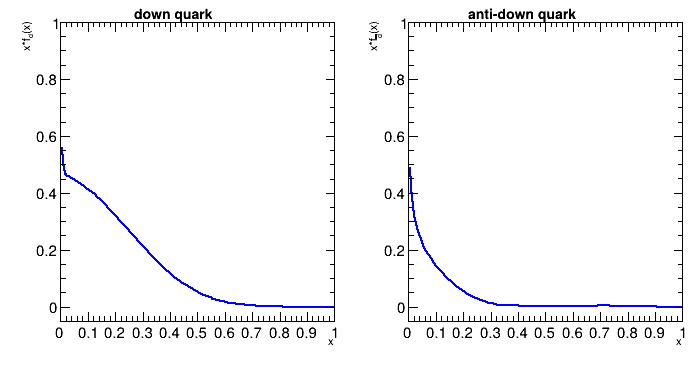

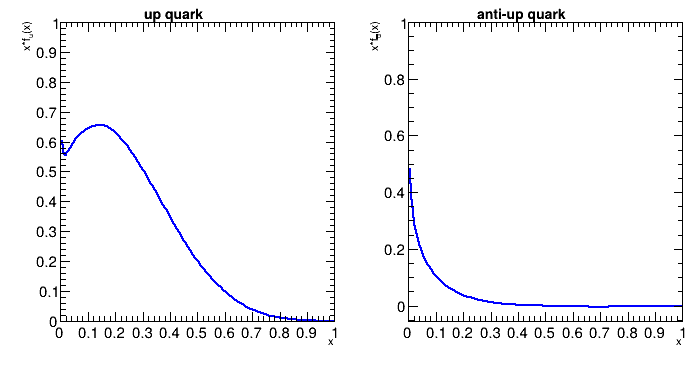

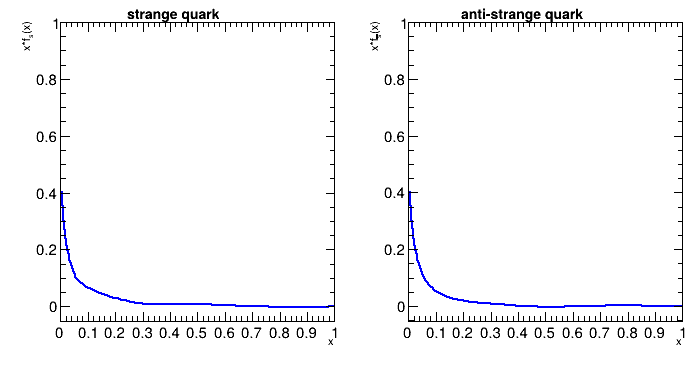

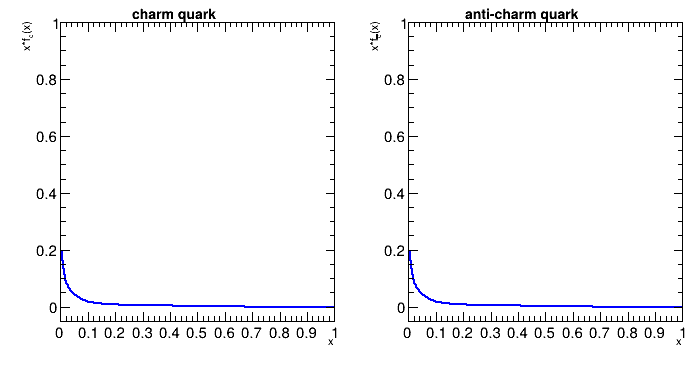

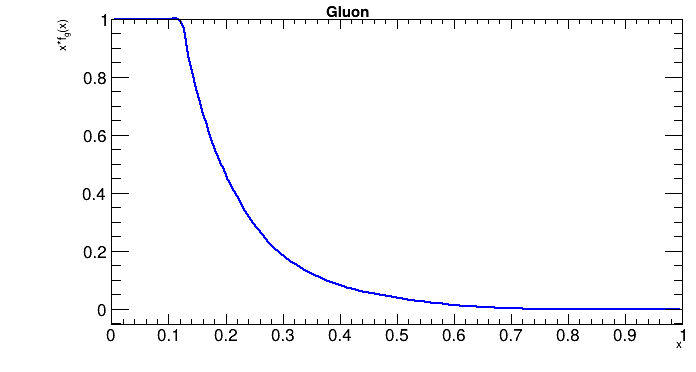

In [6]:
c1 = TCanvas("c1","LHAPDF Example",0,0,700,400)
c2 = TCanvas("c2","LHAPDF Example",0,0,700,400)
c3 = TCanvas("c3","LHAPDF Example",0,0,700,400)
c4 = TCanvas("c4","LHAPDF Example",0,0,700,400)
c5 = TCanvas("c5","LHAPDF Example",0,0,700,400)
c1.Divide(2)
c1.cd(1)
h_d.Draw("c")
h_d.GetXaxis().SetTitle("x")
h_d.GetYaxis().SetTitle("x*f_{d}(x)")
x_d = h_d.Integral("width")


c1.cd(2)
h_ad.Draw("c")
h_ad.GetXaxis().SetTitle("x")
h_ad.GetYaxis().SetTitle("x*f_{#bar{d}}(x)")
x_ad = h_ad.Integral("width")

c2.Divide(2)
c2.cd(1)
h_u.Draw("c")
h_u.GetXaxis().SetTitle("x")
h_u.GetYaxis().SetTitle("x*f_{u}(x)")
x_u = h_u.Integral("width")


c2.cd(2)
h_au.Draw("c")
h_au.GetXaxis().SetTitle("x")
h_au.GetYaxis().SetTitle("x*f_{#bar{u}}(x)")
x_au = h_au.Integral("width")

c3.Divide(2)
c3.cd(1)
h_s.Draw("c")
h_s.GetXaxis().SetTitle("x")
h_s.GetYaxis().SetTitle("x*f_{s}(x)")
x_s = h_s.Integral("width")


c3.cd(2)
h_as.Draw("c")
h_as.GetXaxis().SetTitle("x")
h_as.GetYaxis().SetTitle("x*f_{#bar{s}}(x)")
x_as = h_as.Integral("width")

c4.Divide(2)
c4.cd(1)
h_c.Draw("c")
h_c.GetXaxis().SetTitle("x")
h_c.GetYaxis().SetTitle("x*f_{c}(x)")
x_c = h_c.Integral("width")


c4.cd(2)
h_ac.Draw("c")
h_ac.GetXaxis().SetTitle("x")
h_ac.GetYaxis().SetTitle("x*f_{#bar{c}}(x)")
x_ac = h_ac.Integral("width")

c5.cd()
h_g.Draw("c")
h_g.GetXaxis().SetTitle("x")
h_g.GetYaxis().SetTitle("x*f_{g}(x)")
x_g = h_g.Integral("width")

c1.Update()
c1.Draw()
c2.Update()
c2.Draw()
c3.Update()
c3.Draw()
c4.Update()
c4.Draw()
c5.Update()
c5.Draw()

c1.Print("xF_d.pdf")
c2.Print("xF_u.pdf")
c3.Print("xF_s.pdf")
c4.Print("xF_c.pdf")
c5.Print("xF_g.pdf")

In [7]:
print("Integral down quark = ", x_d)
print("Integral anti-down quark = ", x_ad)
print("Integral up quark = ", x_u)
print("Integral anti-up quark = ", x_au)
print("Integral strange quark = ", x_s)
print("Integral anti-strange quark = ", x_as)
print("Integral up charm = ", x_c)
print("Integral anti-charm quark = ", x_ac)
print("Integral gluon = ", x_g)
print("Total fraction", x_d+x_ad+x_u+x_au + x_s+x_as+x_c+x_ac+x_g)

Integral down quark =  0.13838334831500104
Integral anti-down quark =  0.040171715655950076
Integral up quark =  0.27700651259230663
Integral anti-up quark =  0.030946591267093024
Integral strange quark =  0.024506331799857436
Integral anti-strange quark =  0.020715075282132612
Integral up charm =  0.009213330786708409
Integral anti-charm quark =  0.009277257584089541
Integral gluon =  0.43655991637828273
Total fraction 0.9867800796614214


In [8]:
def get_F2_hist(x_min, x_max, Q2):

    h_d = TH1F("hd" + str(int(Q2)), "down quark", 100, x_min, x_max)
    h_ad = TH1F("had" + str(int(Q2)), "anti-down quark", 100, x_min, x_max)
    h_u = TH1F("hu" + str(int(Q2)), "up quark", 100, x_min, x_max)
    h_au = TH1F("hau" + str(int(Q2)), "anti-up quark", 100, x_min, x_max)
    h_s = TH1F("hs" + str(int(Q2)), "strange quark", 100, x_min, x_max)
    h_as = TH1F("has" + str(int(Q2)), "anti-strange quark", 100, x_min, x_max)
    h_c = TH1F("hc" + str(int(Q2)), "charm quark", 100, x_min, x_max)
    h_ac = TH1F("hac" + str(int(Q)), "anti-charm quark", 100, x_min, x_max)

    for i in range(100):
        x = h_u.GetBinCenter(i + 1)
        h_d.SetBinContent(i + 1, p.xfxQ(1, x, Q2**.5))
        h_ad.SetBinContent(i + 1, p.xfxQ(-1, x, Q2**.5))
        h_u.SetBinContent(i + 1, p.xfxQ(2, x, Q2**.5))
        h_au.SetBinContent(i + 1, p.xfxQ(-2, x, Q2**.5))
        h_s.SetBinContent(i + 1, p.xfxQ(3, x, Q2**.5))
        h_as.SetBinContent(i + 1, p.xfxQ(-3, x, Q2**.5))
        h_c.SetBinContent(i + 1, p.xfxQ(4, x, Q2**.5))
        h_ac.SetBinContent(i + 1, p.xfxQ(-4, x, Q2**.5))

    F2 = TH1F("F2" + str(int(Q2)), "F2(x,Q^2= "+ str(int(Q2)) + "GeV^2)", 100, x_min, x_max)
    F2.SetLineColor(kBlue)
    F2.SetLineWidth(2)
    F2.SetStats(0)
    F2.Add(h_d,1/9)
    F2.Add(h_ad,1/9)
    F2.Add(h_u,4/9)
    F2.Add(h_au,4/9)
    F2.Add(h_s,1/9)
    F2.Add(h_as,1/9)
    F2.Add(h_c,4/9)
    F2.Add(h_ac,4/9)
    return F2



Info in <TCanvas::Print>: pdf file F2.pdf has been created


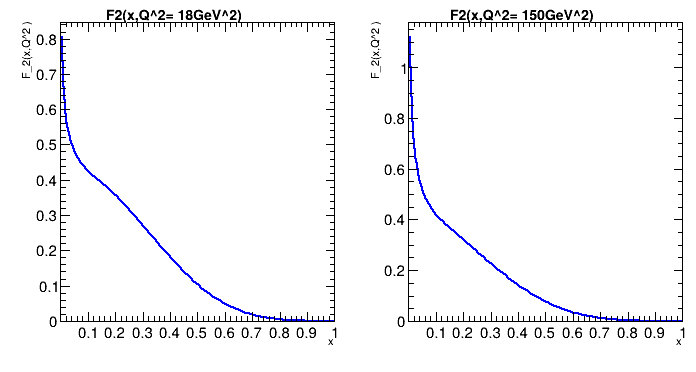

In [9]:
F2_18= get_F2_hist(1e-4,1, 18.0)
F2_150= get_F2_hist(1e-4,1, 150.0)

c= TCanvas("c","F2",0,0,700,400)
c.Divide(2)
c.cd(1)
F2_18.Draw("c")
F2_18.GetXaxis().SetTitle("x")
F2_18.GetYaxis().SetTitle("F_2(x,Q^2 )")

c.cd(2)
F2_150.Draw("c")
F2_150.GetXaxis().SetTitle("x")
F2_150.GetYaxis().SetTitle("F_2(x,Q^2 )")

c.Update()
c.Draw()
c.Print("F2.pdf")


Warning in <TROOT::Append>: Replacing existing TH1: F218 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: F2150 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: pdf file F2_Zoom.pdf has been created


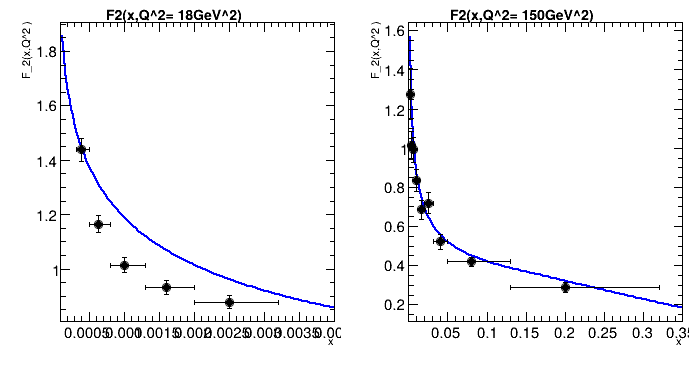

In [10]:
F2_18= get_F2_hist(1e-4,0.004, 18.0)
F2_150= get_F2_hist(1e-4,0.35, 150.0)

c= TCanvas("c","F2",0,0,700,400)
c.Divide(2)
c.cd(1)
F2_18.Draw("c")
F2_18.GetXaxis().SetTitle("x")
F2_18.GetYaxis().SetTitle("F_2(x,Q^2 )")

x   = array('d', [4.0e-4, 6.3e-4, 1.0e-3, 1.6e-3, 2.5e-3, 6.3e-3])
y   = array('d', [1.438, 1.166, 1.015, 0.932, 0.879, 0.629])

# x-errors from bin ranges
exl = array('d', [0.8e-4, 1.3e-4, 0.2e-3, 0.3e-3, 0.5e-3, 3.1e-3])
exh = array('d', [1.0e-4, 1.7e-4, 0.3e-3, 0.4e-3, 0.7e-3, 1.7e-3])

# statistical y-errors
eyl = array('d', [0.041, 0.031, 0.028, 0.026, 0.024, 0.013])
eyh = array('d', [0.041, 0.031, 0.028, 0.026, 0.024, 0.013])

gr18 = TGraphAsymmErrors(len(x), x, y, exl, exh, eyl, eyh)
gr18.SetMarkerStyle(20)
gr18.SetMarkerSize(1.0)
gr18.SetLineWidth(1)
gr18.Draw("P SAME")

c.cd(2)
F2_150.Draw("c")
F2_150.GetXaxis().SetTitle("x")
F2_150.GetYaxis().SetTitle("F_2(x,Q^2 )")


x2   = array('d', [2.5e-3, 4.0e-3, 6.3e-3, 1.0e-2, 1.6e-2, 2.5e-2, 4.0e-2, 8.0e-2, 2.0e-1])
y2   = array('d', [1.275,  1.013,  0.991,  0.835,  0.685,  0.719,  0.522,  0.420,  0.288])

exl2 = array('d', [0.5e-3, 0.8e-3, 1.3e-3, 0.2e-2, 0.3e-2, 0.5e-2, 0.8e-2, 0.3e-1, 0.7e-1])
exh2 = array('d', [0.7e-3, 1.0e-3, 1.7e-3, 0.3e-2, 0.4e-2, 0.7e-2, 1.0e-2, 0.5e-1, 1.2e-1])

eyl2 = array('d', [0.130, 0.070, 0.063, 0.056, 0.050, 0.054, 0.039, 0.022, 0.026])
eyh2 = array('d', [0.130, 0.070, 0.063, 0.056, 0.050, 0.054, 0.039, 0.022, 0.026])

gr150 = TGraphAsymmErrors(len(x2), x2, y2, exl2, exh2, eyl2, eyh2)
gr150.SetMarkerStyle(20)
gr150.SetMarkerSize(1.0)
gr150.SetLineWidth(1)
gr150.Draw("P SAME")




c.Update()
c.Draw()
c.Print("F2_Zoom.pdf")
